# Projection-Collision Analysis

Measures how many Gaussians are projected onto the **same or neighbouring feature-map cells** for each camera view.

**Core question:** does the backbone feature map have enough spatial resolution to provide a *distinct* local descriptor for every Gaussian?  
If a large fraction of Gaussians collapse to the same cell the problem is an upstream resolution bottleneck, not the decoder.

**Prerequisites:**
1. Set `analysis.dump_local_feats: true` in the config and run training for at least one step.
2. The trainer writes `output/analysis/collision_data_<subject>.pt` (alongside `local_feats_<subject>.pt`).

**Figures produced:**
- Capacity overview (image size vs feature-map size vs Gaussian count)
- Per-view exact-cell collision heatmap
- Gaussians-per-cell count histogram + CDF
- 3×3 neighbourhood density heatmap (near-duplicate descriptors)
- Body-region collision map (which SMPL-X vertices are most affected)


## 1 · Configuration

In [1]:
from pathlib import Path

# ── Edit these ────────────────────────────────────────────────────────────────
COLL_PATH = Path("../tmp/analysis/collision_data_0007.pt")   # path to collision_data_*.pt
OUT_DIR   = Path("../tmp/analysis")                          # where to save figures
# ──────────────────────────────────────────────────────────────────────────────

# Auto-discover if the path does not exist
if not COLL_PATH.exists():
    candidates = sorted(Path("../tmp/analysis").glob("collision_data_*.pt"))
    if not candidates:
        raise FileNotFoundError(
            "No collision_data_*.pt files found.\n"
            "Enable analysis.dump_local_feats: true in the config and run training first."
        )
    COLL_PATH = candidates[0]
    print(f"Auto-selected: {COLL_PATH}")

SUBJECT = COLL_PATH.stem.replace("collision_data_", "")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Subject : {SUBJECT}")
print(f"File    : {COLL_PATH.resolve()}")


Subject : 0007
File    : /root/autodl-tmp/work/avatar-benchmark/tmp/analysis/collision_data_0007.pt


## 2 · Imports

In [2]:
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import uniform_filter

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


def save_fig(fig: plt.Figure, name: str) -> None:
    p = OUT_DIR / f"{SUBJECT}_{name}.png"
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"  Saved → {p}")


print("Imports OK")



libgomp: Invalid value for environment variable OMP_NUM_THREADS


Imports OK


## 3 · Load collision metadata & capacity overview

Views                          4
Gaussians (N)                  83,632
Image size                     512 × 512  (262,144 px)
Feature-map size               128 × 128  (16,384 cells)
Stride (px/cell)               4.0 × 4.0
Oversubscription ratio         5.10×  (avg Gaussians per cell; >1 → collision guaranteed)


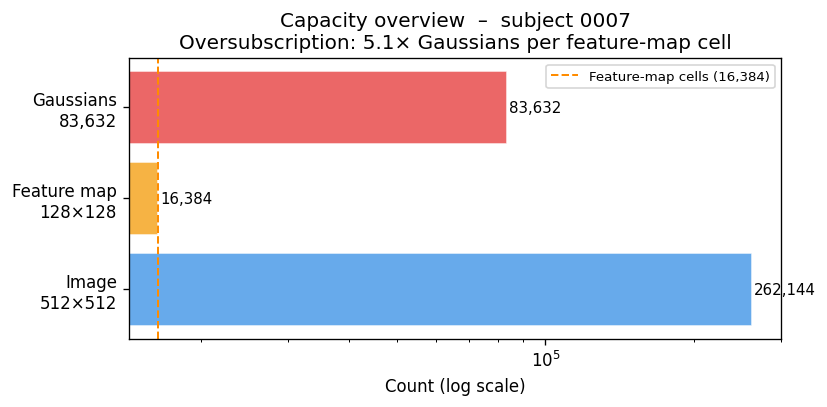

In [3]:
coll = torch.load(COLL_PATH, map_location="cpu", weights_only=True)

# centers2d: (B, N, 2)  –  Gaussian centres in image-pixel coordinates (x, y)
centers2d = coll["centers2d"].float()
H_img, W_img = coll["img_size"]
Hf, Wf       = coll["feat_size"]

B_views, N_gauss, _ = centers2d.shape

stride_h = H_img / Hf
stride_w = W_img / Wf
capacity = Hf * Wf
oversubscription = N_gauss / capacity

print(f"{'Views':<30} {B_views}")
print(f"{'Gaussians (N)':<30} {N_gauss:,}")
print(f"{'Image size':<30} {H_img} × {W_img}  ({H_img*W_img:,} px)")
print(f"{'Feature-map size':<30} {Hf} × {Wf}  ({capacity:,} cells)")
print(f"{'Stride (px/cell)':<30} {stride_h:.1f} × {stride_w:.1f}")
print(f"{'Oversubscription ratio':<30} {oversubscription:.2f}×  "
      f"(avg Gaussians per cell; >1 → collision guaranteed)")

# ── Capacity bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
labels  = [f"Image\n{H_img}×{W_img}", f"Feature map\n{Hf}×{Wf}", f"Gaussians\n{N_gauss:,}"]
values  = [H_img * W_img, capacity, N_gauss]
colors  = ["#4c9be8", "#f5a623", "#e84c4c"]
bars = ax.barh(labels, values, color=colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, values):
    ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
ax.set_title(f"Capacity overview  –  subject {SUBJECT}\n"
             f"Oversubscription: {oversubscription:.1f}× Gaussians per feature-map cell")
ax.axvline(capacity, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"Feature-map cells ({capacity:,})")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4 · Project Gaussians → feature-map cells

In [4]:
# Convert pixel coordinates → feature-map cell indices (align_corners=True convention,
# which matches F.grid_sample used in the trainer):
#   fm_x = x_px * (Wf - 1) / (W_img - 1)
#   fm_y = y_px * (Hf - 1) / (H_img - 1)

fm_x = (centers2d[..., 0] * (Wf - 1) / max(W_img - 1, 1)).round().long()  # (B, N)
fm_y = (centers2d[..., 1] * (Hf - 1) / max(H_img - 1, 1)).round().long()  # (B, N)

# Clamp to valid range (handles Gaussians projected slightly outside the image)
fm_x = fm_x.clamp(0, Wf - 1)
fm_y = fm_y.clamp(0, Hf - 1)

# Flat cell index: (B, N)
cell_idx = fm_y * Wf + fm_x

# Build per-view collision maps  (B, Hf, Wf)
collision_maps = torch.zeros(B_views, Hf, Wf, dtype=torch.long)
for v in range(B_views):
    counts = torch.bincount(cell_idx[v], minlength=capacity)   # (Hf*Wf,)
    collision_maps[v] = counts.view(Hf, Wf)

# Per-view summary
print(f"{'View':<6}  {'Occupied cells':>15}  {'Coverage%':>10}  "
      f"{'Max/cell':>9}  {'Mean (occ)':>11}  {'≥2 cells %':>11}")
print("-" * 70)
for v in range(B_views):
    cm = collision_maps[v]
    occ  = (cm > 0).sum().item()
    cov  = 100.0 * occ / capacity
    mxc  = cm.max().item()
    mo   = cm[cm > 0].float().mean().item()
    gt2  = 100.0 * (cm > 1).sum().item() / max(occ, 1)
    print(f"{v:<6}  {occ:>15,}  {cov:>10.1f}  {mxc:>9}  {mo:>11.2f}  {gt2:>10.1f}%")


View     Occupied cells   Coverage%   Max/cell   Mean (occ)   ≥2 cells %
----------------------------------------------------------------------
0                   451         2.8       6012       185.44        99.3%
1                   445         2.7       6251       187.94        99.1%
2                   594         3.6       5593       140.79        99.8%
3                   580         3.5       4601       144.19        99.7%


## 5 · Per-view exact-cell collision heatmap

  Saved → ../tmp/analysis/0007_collision_heatmap.png


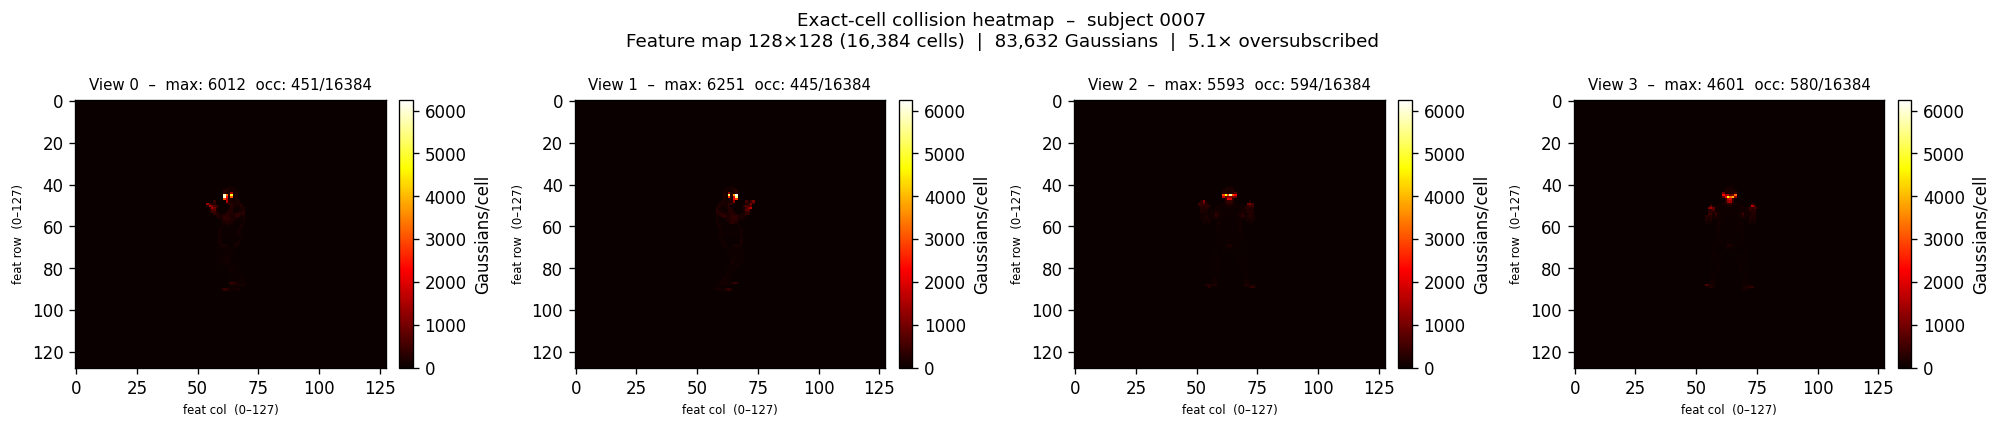

In [5]:
ncols = min(B_views, 4)
nrows = math.ceil(B_views / ncols)
vmax  = collision_maps.max().item()

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4.2, nrows * 3.6),
                          squeeze=False)

for v in range(B_views):
    ax = axes[v // ncols][v % ncols]
    cm = collision_maps[v].numpy()
    im = ax.imshow(cm, origin="upper", cmap="hot", vmin=0, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Gaussians/cell")
    occ = (cm > 0).sum()
    ax.set_title(
        f"View {v}  –  max: {cm.max()}  occ: {occ}/{capacity}",
        fontsize=9,
    )
    ax.set_xlabel(f"feat col  (0–{Wf-1})", fontsize=7)
    ax.set_ylabel(f"feat row  (0–{Hf-1})", fontsize=7)

for v in range(B_views, nrows * ncols):
    axes[v // ncols][v % ncols].axis("off")

fig.suptitle(
    f"Exact-cell collision heatmap  –  subject {SUBJECT}\n"
    f"Feature map {Hf}×{Wf} ({capacity:,} cells)  |  {N_gauss:,} Gaussians  "
    f"|  {oversubscription:.1f}× oversubscribed",
    fontsize=11,
)
fig.tight_layout()
save_fig(fig, "collision_heatmap")
plt.show()


## 6 · Gaussians-per-cell count distribution + CDF

The histogram shows how many feature-map cells contain exactly $k$ Gaussians.  
The CDF shows what fraction of Gaussians experience a given cell occupancy (i.e., how many share the same descriptor).  
$SE = \frac{\sigma}{\sqrt{n}}$ in classic sampling corresponds here to the aliasing due to shared descriptors.

  Saved → ../tmp/analysis/0007_collision_dist.png


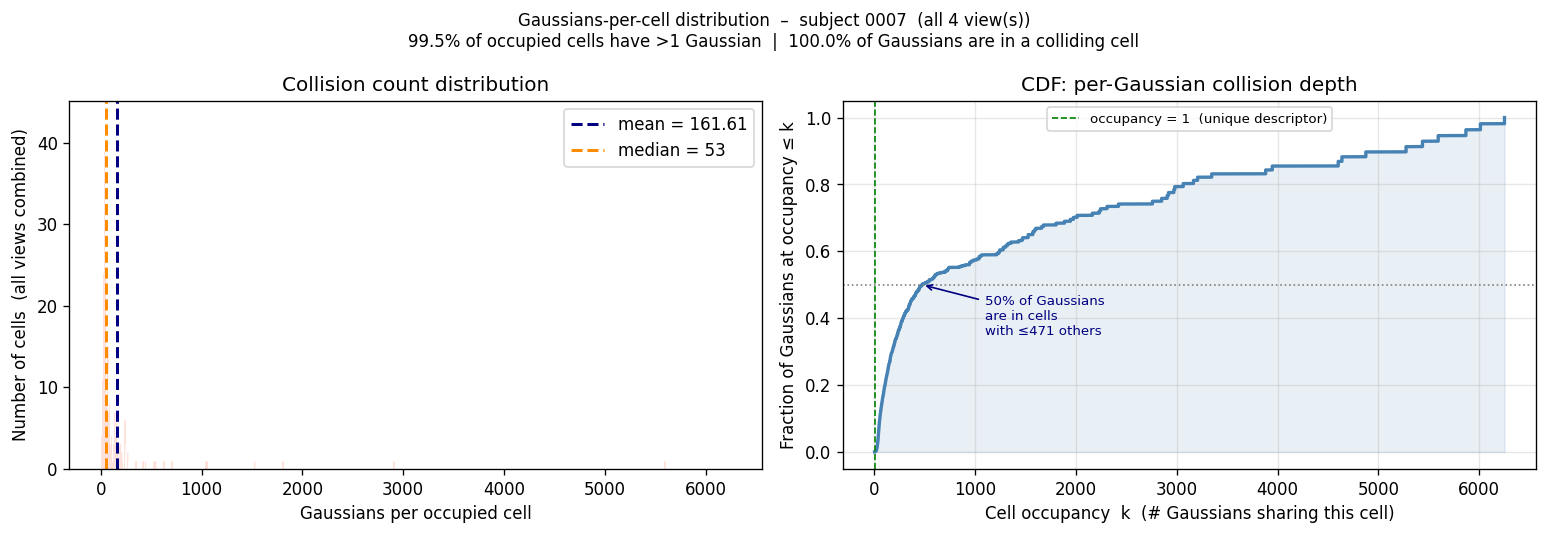


── Collision summary ──
  Occupied cells with > 1 Gaussian:  99.5%
  Gaussians inside a colliding cell:  334,518 / 334,528  (100.0%)
  Theoretical capacity:  16,384 unique descriptors for 83,632 Gaussians  →  min 5.1× oversubscribed


In [6]:
# Aggregate counts across all views; keep only occupied cells
all_counts     = collision_maps.view(-1).numpy()            # (B*Hf*Wf,)
occupied_counts = all_counts[all_counts > 0]               # occupied cells only

max_k = int(occupied_counts.max())

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, (ax_hist, ax_cdf) = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.arange(0.5, max_k + 1.5, 1)
ax_hist.hist(occupied_counts, bins=bins,
             color="tomato", alpha=0.85, edgecolor="white", linewidth=0.4)
ax_hist.axvline(occupied_counts.mean(), color="navy", linewidth=1.8,
                linestyle="--", label=f"mean = {occupied_counts.mean():.2f}")
ax_hist.axvline(float(np.median(occupied_counts)), color="darkorange",
                linewidth=1.8, linestyle="--",
                label=f"median = {np.median(occupied_counts):.0f}")
ax_hist.set_xlabel("Gaussians per occupied cell")
ax_hist.set_ylabel("Number of cells  (all views combined)")
ax_hist.set_title("Collision count distribution")
ax_hist.legend()

# ── CDF: per-Gaussian perspective (what occupancy does each Gaussian experience?)
# Each cell of count c contributes c Gaussians at occupancy c
gauss_occ = np.repeat(
    np.arange(1, max_k + 1),
    np.array([(occupied_counts == k).sum() * k for k in range(1, max_k + 1)]),
)
cdf_x = np.sort(gauss_occ)
cdf_y = np.arange(1, len(cdf_x) + 1) / max(len(cdf_x), 1)

ax_cdf.plot(cdf_x, cdf_y, color="steelblue", linewidth=2.0)
ax_cdf.fill_between(cdf_x, cdf_y, alpha=0.12, color="steelblue")
ax_cdf.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax_cdf.axvline(1,   color="green", linestyle="--", linewidth=1,
               label="occupancy = 1  (unique descriptor)")
p50_occ = cdf_x[np.searchsorted(cdf_y, 0.5)] if len(cdf_y) else 1
ax_cdf.annotate(
    f"50% of Gaussians\nare in cells\nwith ≤{p50_occ} others",
    xy=(p50_occ, 0.5), xytext=(p50_occ + max_k * 0.1, 0.35),
    fontsize=8, color="navy",
    arrowprops=dict(arrowstyle="->", color="navy", lw=1),
)
ax_cdf.set_xlabel("Cell occupancy  k  (# Gaussians sharing this cell)")
ax_cdf.set_ylabel("Fraction of Gaussians at occupancy ≤ k")
ax_cdf.set_title("CDF: per-Gaussian collision depth")
ax_cdf.legend(fontsize=8)
ax_cdf.grid(True, alpha=0.3)

# Collision statistics printout
pct_colliding   = 100.0 * (occupied_counts > 1).sum() / max(len(occupied_counts), 1)
gauss_in_coll   = int((collision_maps[collision_maps > 1]).sum().item())
total_gauss_all = B_views * N_gauss
fig.suptitle(
    f"Gaussians-per-cell distribution  –  subject {SUBJECT}  (all {B_views} view(s))\n"
    f"{pct_colliding:.1f}% of occupied cells have >1 Gaussian  |  "
    f"{100.0*gauss_in_coll/max(total_gauss_all,1):.1f}% of Gaussians are in a colliding cell",
    fontsize=10,
)
fig.tight_layout()
save_fig(fig, "collision_dist")
plt.show()

print(f"\n── Collision summary ──")
print(f"  Occupied cells with > 1 Gaussian:  {pct_colliding:.1f}%")
print(f"  Gaussians inside a colliding cell:  "
      f"{gauss_in_coll:,} / {total_gauss_all:,}  "
      f"({100.0*gauss_in_coll/max(total_gauss_all,1):.1f}%)")
print(f"  Theoretical capacity:  {capacity:,} unique descriptors for "
      f"{N_gauss:,} Gaussians  →  min {oversubscription:.1f}× oversubscribed")


## 7 · 3×3 neighbourhood density heatmap

Even when two Gaussians land in *adjacent* cells they receive nearly identical features due to bilinear interpolation in `F.grid_sample`.  
This map sums every cell's 3×3 neighbourhood and shows where clusters of near-duplicate descriptors live.

  Saved → ../tmp/analysis/0007_collision_neighborhood.png


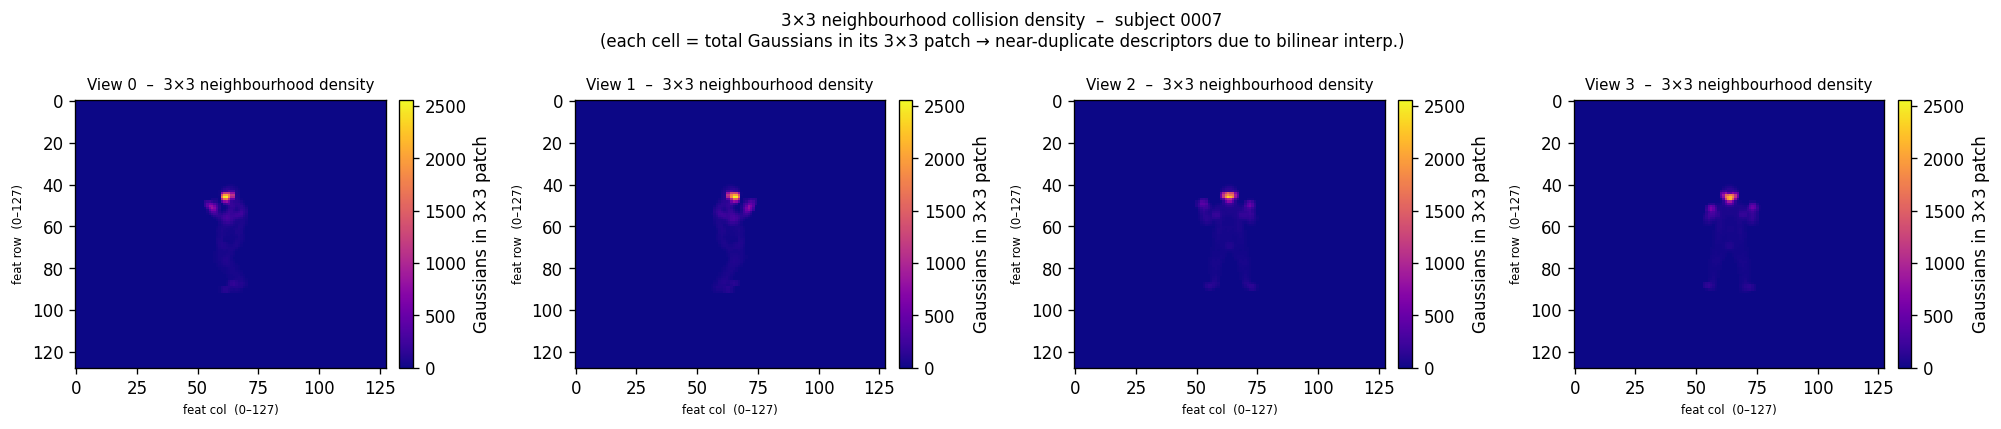

Gaussians with ≥1 neighbour in 3×3 patch: 100.0%  (near-duplicate descriptor)


In [7]:
nb_maps = [
    uniform_filter(collision_maps[v].numpy().astype(float), size=3,
                   mode="constant", cval=0.0)
    for v in range(B_views)
]
vmax_nb = max(m.max() for m in nb_maps)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4.2, nrows * 3.6),
                          squeeze=False)
for v in range(B_views):
    ax = axes[v // ncols][v % ncols]
    im = ax.imshow(nb_maps[v], origin="upper", cmap="plasma",
                   vmin=0, vmax=vmax_nb,
                   interpolation="nearest", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Gaussians in 3×3 patch")
    ax.set_title(f"View {v}  –  3×3 neighbourhood density", fontsize=9)
    ax.set_xlabel(f"feat col  (0–{Wf-1})", fontsize=7)
    ax.set_ylabel(f"feat row  (0–{Hf-1})", fontsize=7)

for v in range(B_views, nrows * ncols):
    axes[v // ncols][v % ncols].axis("off")

fig.suptitle(
    f"3×3 neighbourhood collision density  –  subject {SUBJECT}\n"
    "(each cell = total Gaussians in its 3×3 patch → near-duplicate descriptors due to bilinear interp.)",
    fontsize=10,
)
fig.tight_layout()
save_fig(fig, "collision_neighborhood")
plt.show()

# What fraction of Gaussians are indistinguishable under 3×3 neighbourhood?
nb_per_gauss = np.array([
    nb_maps[v][fm_y[v].numpy(), fm_x[v].numpy()]
    for v in range(B_views)
]).ravel()
pct_nb_gt1 = 100.0 * (nb_per_gauss > 1).mean()
print(f"Gaussians with ≥1 neighbour in 3×3 patch: {pct_nb_gt1:.1f}%  "
      f"(near-duplicate descriptor)")


## 8 · Spatial collision map in image space

Scatter each Gaussian back to its image-pixel location and colour by cell occupancy.  
Hot spots show which body regions are most over-sampled relative to the feature map.

  Saved → ../tmp/analysis/0007_collision_image_space.png


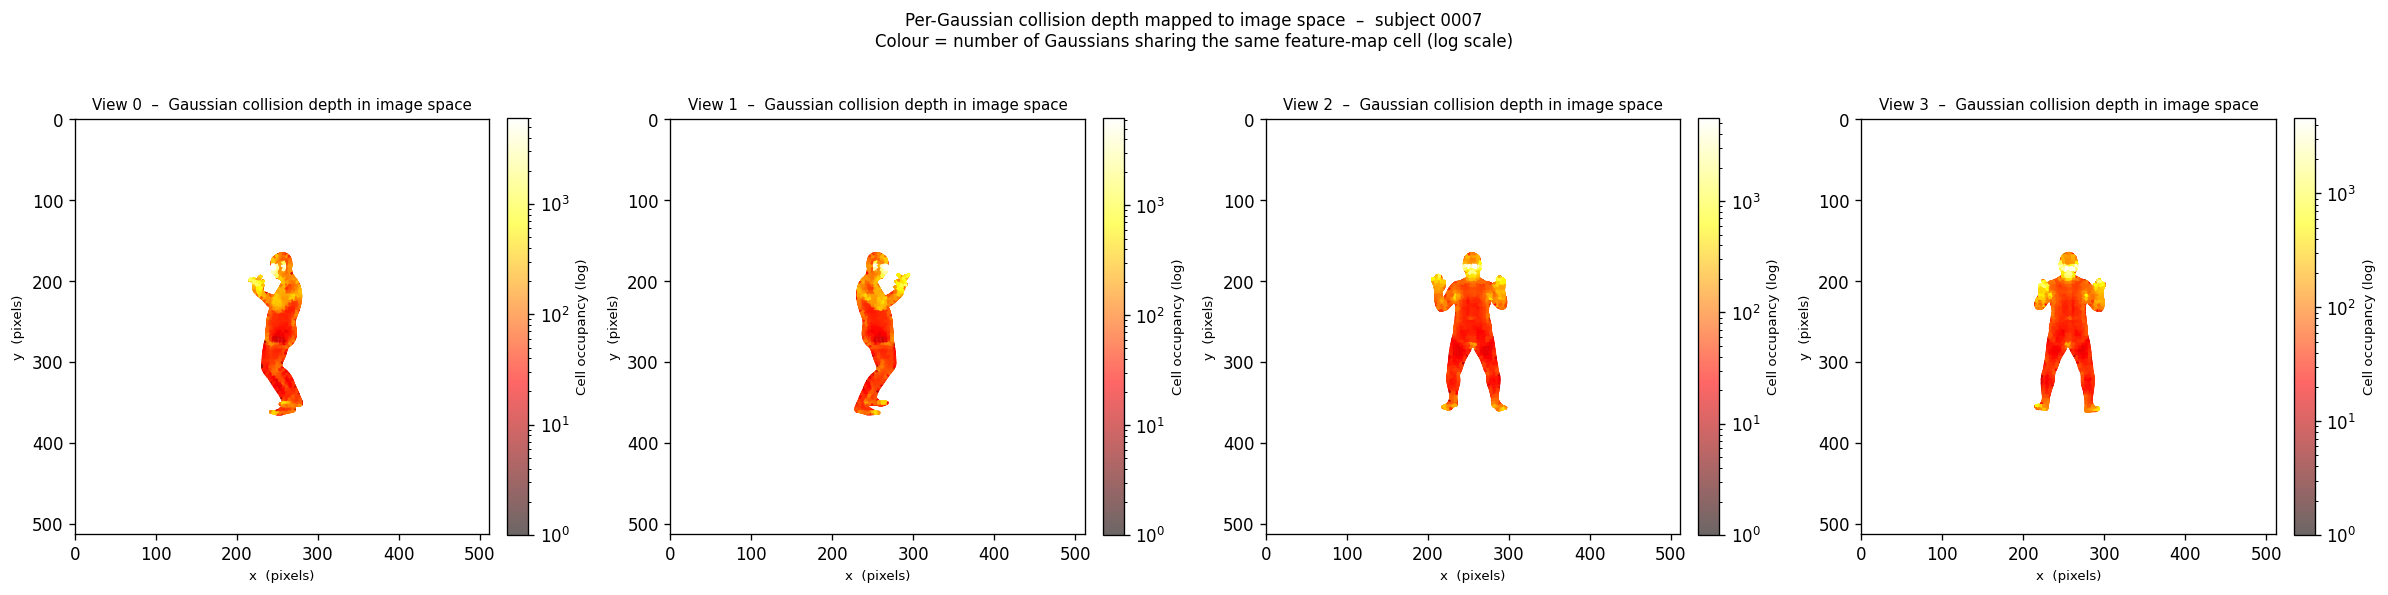

In [8]:
fig, axes = plt.subplots(1, B_views,
                          figsize=(B_views * 5, 5),
                          squeeze=False)

for v in range(B_views):
    ax = axes[0][v]
    # Occupancy value experienced by each Gaussian in this view
    occ_per_gauss = collision_maps[v][fm_y[v], fm_x[v]].numpy().astype(float)

    sc = ax.scatter(
        centers2d[v, :, 0].numpy(),   # x pixel
        centers2d[v, :, 1].numpy(),   # y pixel
        c=occ_per_gauss,
        cmap="hot",
        norm=mcolors.LogNorm(vmin=1, vmax=max(occ_per_gauss.max(), 2)),
        s=1.5,
        alpha=0.6,
        linewidths=0,
        rasterized=True,
    )
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Cell occupancy (log)", fontsize=8)

    ax.set_xlim(0, W_img)
    ax.set_ylim(H_img, 0)   # image-coordinate origin top-left
    ax.set_aspect("equal")
    ax.set_title(f"View {v}  –  Gaussian collision depth in image space", fontsize=9)
    ax.set_xlabel("x  (pixels)", fontsize=8)
    ax.set_ylabel("y  (pixels)", fontsize=8)

fig.suptitle(
    f"Per-Gaussian collision depth mapped to image space  –  subject {SUBJECT}\n"
    "Colour = number of Gaussians sharing the same feature-map cell (log scale)",
    fontsize=10,
)
fig.tight_layout()
save_fig(fig, "collision_image_space")
plt.show()


## 9 · Sampling-error metrics

Quantify the collision problem with scalar metrics, analogous to sampling-theory error measures.

| Metric | Formula | Interpretation |
|---|---|---|
| Oversubscription ratio | $N / (H_f \cdot W_f)$ | Average Gaussians per cell |
| Unique-descriptor rate | $\|\\{(i,j): c_{ij}=1\\}\| \;/\; N$ | Fraction of Gaussians with a unique local feature |
| Mean collision depth | $\bar{c}$ over occupied cells | Average Gaussians competing per cell |
| Effective resolution | $H_f \cdot W_f \;/\; N$ | Feature cells available per Gaussian ($< 1$ = aliased) |

In [9]:
rows = []
for v in range(B_views):
    cm         = collision_maps[v]
    occ_cells  = (cm > 0).sum().item()
    unique_g   = (cm == 1).sum().item()       # Gaussians with no collision
    total_g    = N_gauss
    coll_g     = total_g - unique_g
    mean_depth = cm[cm > 0].float().mean().item() if occ_cells else 0.0
    eff_res    = capacity / max(total_g, 1)
    rows.append({
        "View":                 v,
        "Oversubscription (×)": f"{oversubscription:.2f}",
        "Unique-descriptor %":  f"{100.0 * unique_g / max(total_g, 1):.1f}",
        "Collision %":          f"{100.0 * coll_g / max(total_g, 1):.1f}",
        "Mean collision depth": f"{mean_depth:.2f}",
        "Effective resolution": f"{eff_res:.4f}",
    })

import pandas as pd
df = pd.DataFrame(rows).set_index("View")
print(df.to_string())

# bar chart of unique-descriptor rate per view
fig, ax = plt.subplots(figsize=(max(5, B_views * 1.4), 4))
udr = [float(r["Unique-descriptor %"]) for r in rows]
bars = ax.bar(range(B_views), udr, color=["#4c9be8"] * B_views,
              edgecolor="white", alpha=0.85)
ax.axhline(100.0 / oversubscription, color="red", linestyle="--", linewidth=1.5,
           label=f"Expected unique rate if uniform ({100.0/oversubscription:.1f}%)")
for bar, u in zip(bars, udr):
    ax.text(bar.get_x() + bar.get_width() / 2, u + 0.5,
            f"{u:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 105)
ax.set_xlabel("View index")
ax.set_ylabel("Gaussians with a unique feature-map cell (%)")
ax.set_title(f"Unique-descriptor rate per view  –  subject {SUBJECT}\n"
             f"(100% = every Gaussian lands in its own cell; "
             f"aliasing guaranteed below {100.0/oversubscription:.0f}%)")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "collision_unique_rate")
plt.show()


ModuleNotFoundError: No module named 'pandas'

## 10 · Required feature-map resolution

How large would the feature map need to be to achieve a target unique-descriptor rate?  
Assumes Gaussians are distributed uniformly (worst case).

In [ ]:
# Birthday-problem approximation: probability that all N items land in M distinct bins ≈
#   P_unique ≈ exp(-N*(N-1) / (2*M))
# Solving for M given target P_unique:
#   M_required = -N*(N-1) / (2 * ln(P_unique))

target_rates = [0.50, 0.75, 0.90, 0.95, 0.99]
print(f"{'Target unique %':>17}  {'Required cells (M)':>19}  {'Required (√M)×(√M)':>20}  {'× current':>10}")
print("-" * 75)

current_cells = Hf * Wf
for p in target_rates:
    M_req = -N_gauss * (N_gauss - 1) / (2.0 * math.log(p))
    side  = math.sqrt(M_req)
    mult  = M_req / max(current_cells, 1)
    print(f"{p*100:>16.0f}%  {M_req:>19,.0f}  {side:>14.0f}×{side:<4.0f}         {mult:>9.1f}×")

# Plot: unique-descriptor rate vs feature-map size
M_range = np.logspace(
    math.log10(current_cells / 10),
    math.log10(N_gauss * 10),
    300,
)
p_unique = np.exp(-N_gauss * (N_gauss - 1) / (2.0 * M_range))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(M_range, p_unique * 100, color="steelblue", linewidth=2)
ax.axvline(current_cells, color="red", linestyle="--", linewidth=1.5,
           label=f"Current: {Hf}×{Wf} = {current_cells:,} cells")
ax.axvline(N_gauss, color="green", linestyle=":", linewidth=1.2,
           label=f"N Gaussians = {N_gauss:,}")
for p in [50, 90, 99]:
    ax.axhline(p, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.text(M_range[0] * 1.1, p + 0.8, f"{p}%", fontsize=7, color="gray")
ax.set_xlabel("Feature-map capacity  M  (number of cells, log scale)")
ax.set_ylabel("Expected unique-descriptor rate (%)")
ax.set_title(
    f"Required feature-map resolution vs unique-descriptor rate\n"
    f"N = {N_gauss:,} Gaussians  –  birthday-problem approximation"
)
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
fig.tight_layout()
save_fig(fig, "collision_required_resolution")
plt.show()


## 11 · Summary

Run this cell for a final diagnostic printout.

In [ ]:
sep = "=" * 60
print(sep)
print(f"  Projection-Collision Summary  –  subject {SUBJECT}")
print(sep)
print(f"  Image size         : {H_img} × {W_img}")
print(f"  Feature-map size   : {Hf} × {Wf}  ({capacity:,} cells)")
print(f"  Stride             : {stride_h:.1f} × {stride_w:.1f} px / cell")
print(f"  Gaussians (N)      : {N_gauss:,}")
print(f"  Oversubscription   : {oversubscription:.2f}×")
print()
for v in range(B_views):
    cm     = collision_maps[v]
    occ    = (cm > 0).sum().item()
    uniq   = (cm == 1).sum().item()
    coll_g = N_gauss - uniq
    mx     = cm.max().item()
    mo     = cm[cm > 0].float().mean().item() if occ else 0.0
    print(f"  View {v}:")
    print(f"    Occupied cells       : {occ:,} / {capacity:,}  "
          f"({100.0*occ/capacity:.1f}%)")
    print(f"    Unique descriptors   : {uniq:,} / {N_gauss:,}  "
          f"({100.0*uniq/max(N_gauss,1):.1f}%)")
    print(f"    Colliding Gaussians  : {coll_g:,} / {N_gauss:,}  "
          f"({100.0*coll_g/max(N_gauss,1):.1f}%)")
    print(f"    Max Gaussians/cell   : {mx}")
    print(f"    Mean depth (occupied): {mo:.2f}")
    print()

print(sep)
print("  Figures saved to:", OUT_DIR.resolve())
print(sep)
